In [1]:
!pip install pandas scikit-learn

In [3]:
import pandas as pd

# Load your CSV
df = pd.read_csv("waste_dataset.csv")

# Preview
df.head()

,item,category,description,impact,disposal_methods
0,Banana Peel,wet,Biodegradable fruit skin,Attracts pests and produces methane,Compost;Use as fertilizer;Vermicompost
1,Apple Core,wet,Organic fruit waste,Methane production in landfill,Compost;Feed animals;Worm bin
2,Orange Peel,wet,Citrus fruit skin,Slow decomposition in mixed waste,Compost;Natural cleaner;Dry reuse
3,Watermelon Rind,wet,Thick fruit skin,Takes landfill space,Compost;Cook reuse;Biogas
4,Mango Peel,wet,Tropical fruit skin,Attracts flies if unmanaged,Compost;Animal feed;Vermicompost


In [4]:
# Convert to lowercase
df['item_clean'] = df['item'].str.lower()

# Features (input)
X = df['item_clean']

# Labels (what we predict)
y = df['item']

In [7]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nData Types:\n", df.dtypes)

Shape: (73, 6)

Columns:
 Index(['item', 'category', 'description', 'impact', 'disposal_methods',
       'item_clean'],
      dtype='object')

Data Types:
 item                object
category            object
description         object
impact              object
disposal_methods    object
item_clean          object
dtype: object


In [8]:
df.isnull().sum()

,0
item,0
category,0
description,0
impact,0
disposal_methods,0
item_clean,0


In [9]:
df = df.dropna()

In [10]:
df['category'].value_counts()

,count
category,
wet,23
dry,20
ewaste,19
hazardous,11


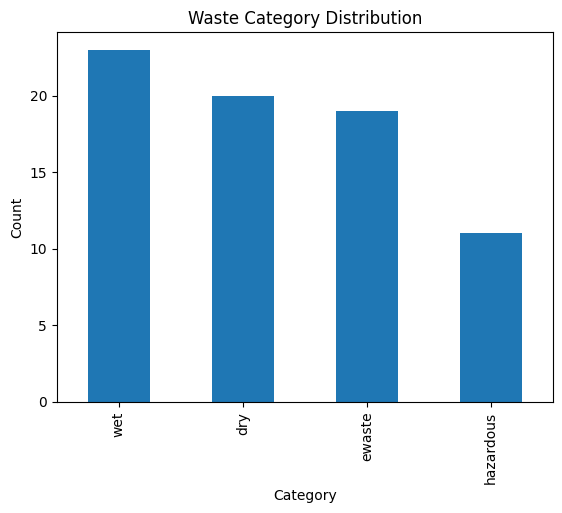

In [11]:
import matplotlib.pyplot as plt

df['category'].value_counts().plot(kind='bar')
plt.title("Waste Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

In [12]:
from collections import Counter

words = " ".join(df['item_clean']).split()
Counter(words).most_common(10)

[('peel', 5),
 ('leaves', 3),
 ('plastic', 3),
 ('bottle', 3),
 ('can', 3),
 ('battery', 3),
 ('leftover', 2),
 ('clippings', 2),
 ('paper', 2),
 ('glass', 2)]

In [13]:
all_methods = df['disposal_methods'].str.split(";").explode()

all_methods.value_counts()

,count
disposal_methods,
Compost,23
Recycle,21
Reuse,18
E-waste recycling,16
Vermicompost,7
Mulch,6
Donate,5
Animal feed,5
Bokashi,4


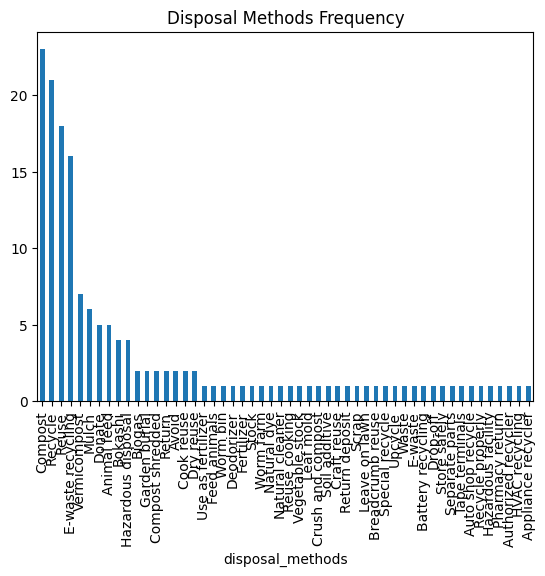

In [19]:
all_methods.value_counts().plot(kind='bar')
plt.title("Disposal Methods Frequency")
plt.xticks(rotation=90)
plt.show()

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X_vectorized = vectorizer.fit_transform(X)

In [21]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_vectorized, y)

LogisticRegression()

In [22]:
def predict_item(user_input):
    user_input = user_input.lower()

    # Convert input to vector
    input_vec = vectorizer.transform([user_input])

    # Predict item
    predicted_item = model.predict(input_vec)[0]

    # Get full details from dataset
    result = df[df['item'] == predicted_item].iloc[0]

    return {
        "input": user_input,
        "matched_item": predicted_item,
        "category": result['category'],
        "description": result['description'],
        "impact": result['impact'],
        "disposal_methods": result['disposal_methods']
    }

In [25]:
print(predict_item("banana"))

{'input': 'banana', 'matched_item': 'Banana Peel', 'category': 'wet', 'description': 'Biodegradable fruit skin', 'impact': 'Attracts pests and produces methane', 'disposal_methods': 'Compost;Use as fertilizer;Vermicompost'}


In [26]:
method_scores = {
    "Compost": 17,
    "Vermicompost": 16,
    "Biogas": 15,
    "Recycle": 16,
    "Reuse": 15,
    "Animal feed": 15
}

def rank_methods(methods_str):
    methods = methods_str.split(";")

    ranked = []
    for m in methods:
        score = method_scores.get(m.strip(), 10)
        ranked.append((m.strip(), score))

    ranked.sort(key=lambda x: x[1], reverse=True)
    return ranked

In [27]:
def full_prediction(user_input):
    data = predict_item(user_input)

    ranked = rank_methods(data['disposal_methods'])

    data['recommendations'] = ranked
    return data

In [34]:
result = full_prediction("Plastic Bottle")

print("Input:", result['input'])
print("Matched Item:", result['matched_item'])
print("Category:", result['category'])
print("Description:", result['description'])
print("Impact:", result['impact'])

print("\nBest Disposal Methods:")
for i, (method, score) in enumerate(result['recommendations'], 1):
    print(f"{i}. {method} (Score: {score})")

Input: plastic bottle
Matched Item: Plastic Bottle PET
Category: dry
Description: Drink bottle
Impact: Long decomposition

Best Disposal Methods:
1. Recycle (Score: 16)
2. Reuse (Score: 15)
3. Return deposit (Score: 10)


In [35]:
import pickle

# Save model
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

# Save vectorizer
with open("vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

# Save dataset
df.to_csv("cleaned_dataset.csv", index=False)